In [1]:
import pandas as pd
from pathlib import Path
import json
from tqdm.rich import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import MaxNLocator, ScalarFormatter
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import skew, kurtosis

colors = ["#F0741E", "#276CB3"]

plt.style.use("seaborn-v0_8-paper")

save_path=Path("./plots")
save_path.mkdir(exist_ok=True, parents=True)

/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

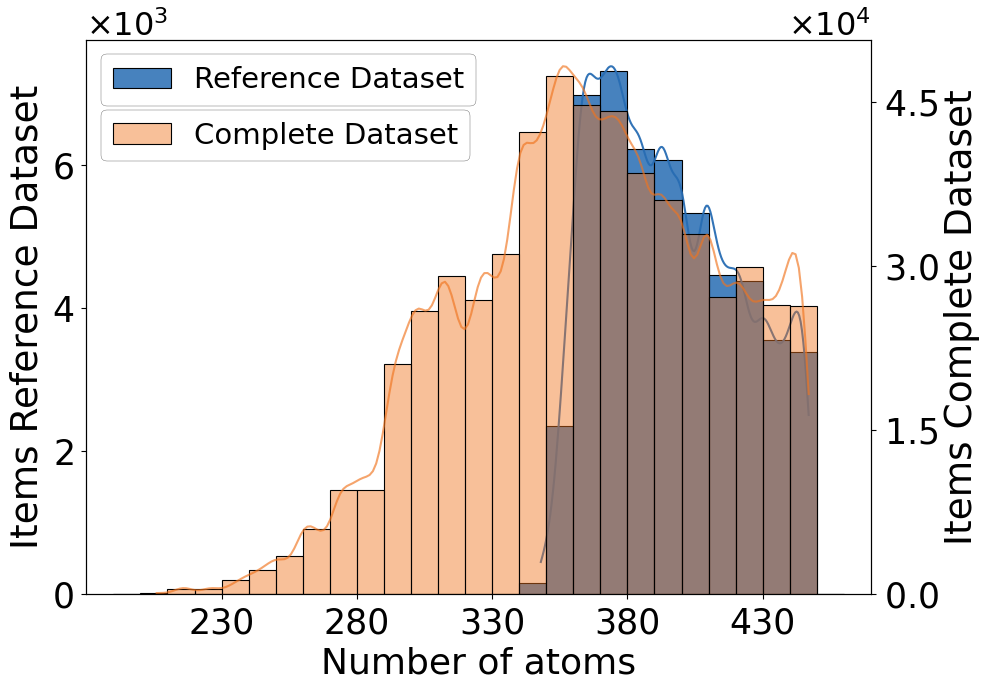

In [4]:
df = pd.read_csv("/home/tommaso/xyz_files_G/dataset_complete_with_atoms_count.csv")

df_reference = pd.read_csv(Path("./dataset_sorted.csv"))

min_value = 190 #df["n_atoms"].min()
max_value = 460 #df["n_atoms"].max()
binwidth = 10
bins = np.arange(min_value, max_value + binwidth, binwidth)


fig, ax1 = plt.subplots(figsize=(10, 7))
ax2 = ax1.twinx()
sns.histplot(data=df_reference, x="initial_num_atoms", ax=ax1, bins=bins, kde=True, label='Reference Dataset', color=colors[1], stat='count',linewidth=0.8, alpha=0.85, line_kws={'alpha':0.95,"linewidth":1.5})
sns.histplot(data=df, x="n_atoms", ax=ax2, bins=bins, kde=True, label='Complete Dataset', color=colors[0], stat='count',linewidth=0.8, alpha=0.45, line_kws={'alpha':0.65,"linewidth":1.5})

# Sincronizza i limiti degli assi
ax1.set_xlim([min_value-binwidth, max_value+binwidth])
ax2.set_xlim([min_value-binwidth, max_value+binwidth])

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1,1))
ax1.yaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)
# Ingrandisci la notazione esponenziale sull'asse y1
ax1.yaxis.get_offset_text().set_fontsize(23)  # Modifica la dimensione del font per l'offset
# Ingrandisci la notazione esponenziale sull'asse y2
ax2.yaxis.get_offset_text().set_fontsize(23)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc='upper left', fontsize=21, edgecolor='black',bbox_to_anchor=(0, 1))
ax2.legend(lines2, labels2, loc='upper left', fontsize=21, edgecolor='black',bbox_to_anchor=(0, 0.9))
ax1.tick_params(axis="both", which="major", labelsize=25)
ax2.tick_params(axis="both", which="major", labelsize=25)
ax1.set_xlabel("Number of atoms",size=26)
ax1.set_ylabel('Items Reference Dataset',size=27)
ax2.set_ylabel('Items Complete Dataset',size=27)
ax1.set_xticks((230,280,330,380,430))
#ax1.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax1.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax2.yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.tight_layout()
fig.savefig(save_path.joinpath(f"distribution_n_atoms_overlap_datasets.png"),dpi=300,bbox_inches="tight")
plt.show()
plt.close()

Start here the validation process

Energy validation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

In [3]:
df_trained = pd.read_csv('/home/mario/jobs/AutoDFTB/paper/dataset.csv')

df_complete = pd.read_csv('/home/mario/xyz_files_G/dataset_with_energy_per_atom_new.csv')


In [4]:
df_trained['energy_per_atom_dftb'] = df_trained['total_energy'] / df_trained['num_atoms']
comparison = df_complete[df_complete['file_name'].isin(df_trained['file_name'])][['file_name', 'energy_per_atom']]
comparison['dftb'] = df_trained['energy_per_atom_dftb'] + 40 #scaling offset 
print(comparison.head())


          file_name  energy_per_atom      dftb
24  graphene_203308          -9.0898 -9.030315
25  graphene_299934          -8.8487 -9.122439
31  graphene_319108          -8.9615 -9.120627
33  graphene_197833          -8.9915 -8.988854
43  graphene_302209          -9.0262 -9.095308


MAE  = 0.020188
RMSE = 0.025488
R²   = 0.872191


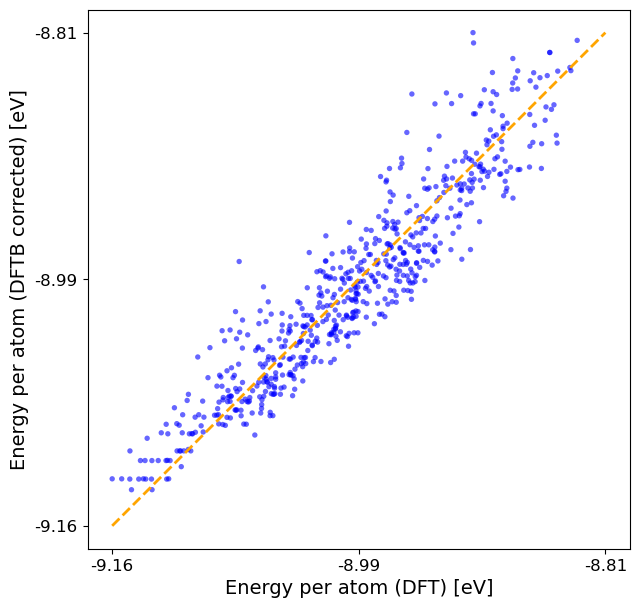

In [5]:


# Merge for alignment
merged = df_trained.merge(df_complete[['file_name', 'energy_per_atom']], on='file_name', how='inner')
merged.rename(columns={'energy_per_atom': 'energy_ref', 'energy_per_atom_dftb': 'energy_dftb'}, inplace=True)

# Bias correction
bias_opt = (merged['energy_ref'] - merged['energy_dftb']).mean()
merged['energy_dftb_corr'] = merged['energy_dftb'] + bias_opt

# Subsample 5000 random samples
sample = merged.sample(n=min(5000, len(merged)), random_state=42)

# Metrics
y_true = sample['energy_ref']
y_pred = sample['energy_dftb_corr']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE  = {mae:.6f}")
print(f"RMSE = {rmse:.6f}")
print(f"R²   = {r2:.6f}")

# Scatter plot
plt.figure(figsize=(7,7))
plt.scatter(y_true, y_pred, color='blue', alpha=0.6, s=15, edgecolors='none')

# Bisector line (orange)
lims = [
    np.min([y_true.min(), y_pred.min()]),
    np.max([y_true.max(), y_pred.max()])
]
plt.plot(lims, lims, '--', color='orange', linewidth=2)

# Axis formatting
plt.xlabel('Energy per atom (DFT) [eV]', fontsize=14)
plt.ylabel('Energy per atom (DFTB corrected) [eV]', fontsize=14)
plt.xlim(lims)
plt.ylim(lims)

# Rounded tick values (2 decimals)
xticks = np.linspace(lims[0], lims[1], 3)
yticks = np.linspace(lims[0], lims[1], 3)
plt.xticks(xticks, [f"{x:.2f}" for x in xticks], fontsize=12)
plt.yticks(yticks, [f"{y:.2f}" for y in yticks], fontsize=12)

#plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()


Start here the validation of the data with different slakos parameter and different scc_tolerance

In [6]:
import json
import pandas as pd
from pathlib import Path

data_batch = [2,3,4,5,6,7,8,9,10,11,12,13,14]
records = []

for b in data_batch:
    rep_path = Path.cwd().parent.joinpath(f"data_batch_{b}/dftb/repulsive")
    json_list = rep_path.glob("*.json")

    for file in json_list:
        try:
            with open(file) as f:
                data = json.load(f)
                file_name = data.get("file_name")
                rep_energy = data.get("repulsive_energy_ev")
                records.append({
                    "batch": b,
                    "file_name": file_name,
                    "repulsive_energy_ev": rep_energy
                })
        except Exception as e:
            print(f"Errore nel file {file}: {e}")

repulsive_df = pd.DataFrame(records)
repulsive_df['file_name'] = repulsive_df['file_name'].str.replace('_opt$', '', regex=True)
print(repulsive_df.head())


   batch        file_name  repulsive_energy_ev
0      2  graphene_433026             811.9786
1      2   graphene_50070             801.9358
2      2   graphene_94707             885.8424
3      2   graphene_40321             941.8420
4      2  graphene_358114             913.4828


In [ ]:
csv_mod = pd.read_csv("/home/mario/jobs/AutoDFTB/DATA_VALIDATION/batch/dataset.csv")
csv_ref = pd.read_csv('/home/mario/jobs/AutoDFTB/paper/dataset.csv')
merged = pd.merge(
    csv_mod,
    repulsive_df[['file_name', 'repulsive_energy_ev']],
    on='file_name',
    how='inner'  # solo file comuni
)

# Calcola la formation energy
merged['formation_energy_ev'] = merged['total_energy'] - merged['repulsive_energy_ev']
merged['formation_energy_ev_per_atom'] = merged['formation_energy_ev'] / merged['num_atoms']
# (Opzionale) verifica
print(merged[['file_name', 'total_energy', 'repulsive_energy_ev', 'formation_energy_ev']].head())

csv_mod = pd.merge(
    csv_mod,
    merged[['file_name', 'formation_energy_ev']],
    on='file_name',
    how='left'
)



         file_name  total_energy  repulsive_energy_ev  formation_energy_ev
0  graphene_501625   -20365.8407             791.2359          -21157.0766
1  graphene_515304   -21125.9644             823.3374          -21949.3018
2  graphene_395504   -20519.4173             809.5111          -21328.9284
3  graphene_464046   -21711.9649             859.3525          -22571.3174
4  graphene_154324   -21344.1208             840.2576          -22184.3784


In [11]:
csv_ref['electron_affinity'] = -csv_ref['electron_affinity']
csv_ref['ionization_potential'] = -csv_ref['ionization_potential']

[Val] Common files: 1132
         file_name  total_energy_ref  ionization_potential_ref  \
0   graphene_10025       -24850.8988                    4.6956   
1   graphene_10145       -25029.1812                    4.7106   
2  graphene_101515       -23790.8117                    4.8368   
3  graphene_102179       -24920.7656                    4.7220   
4  graphene_102519       -20710.6304                    5.0977   

   electron_affinity_ref  band_gap_ref  Fermi_energy_ref  current_ref  \
0                 4.8545        0.1589           -4.7701     0.000006   
1                 4.9257        0.2151           -4.7793     0.000010   
2                 5.0036        0.1668           -4.9013     0.000005   
3                 4.9069        0.1849           -4.7735     0.000009   
4                 5.2571        0.1594           -5.1327     0.000003   

   num_atoms  formation_energy_ev  total_energy_mod  ionization_potential_mod  \
0        506          -24778.0111       -23860.8770       

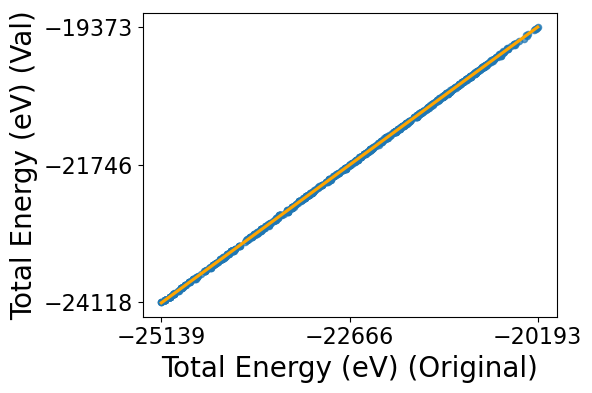

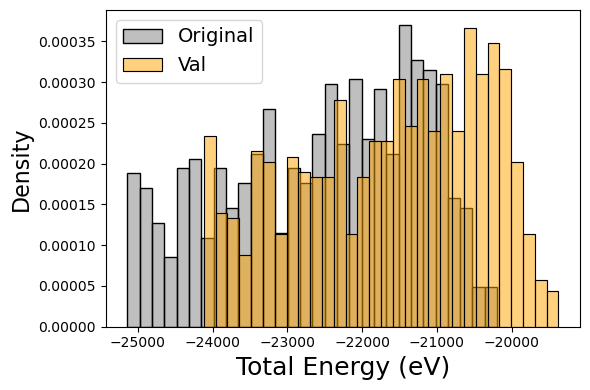

ionization_potential      | -0.254 |     0.1297 |     0.0510


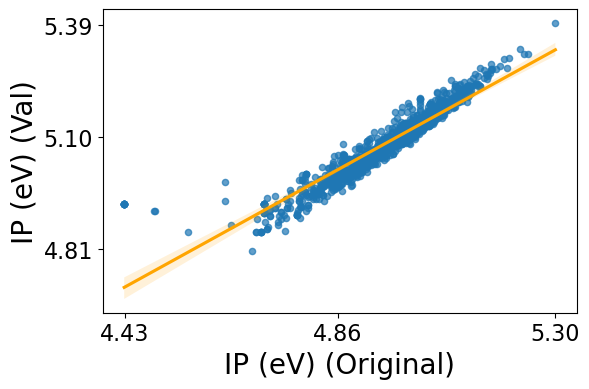

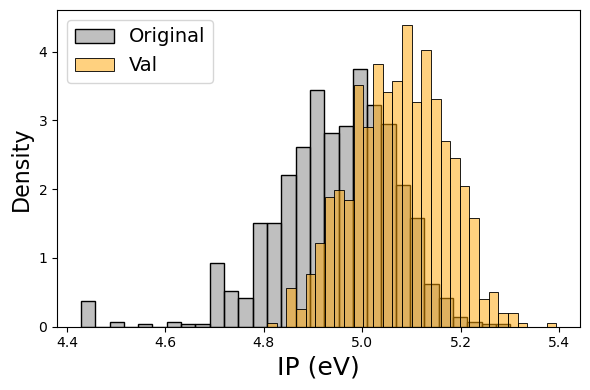

electron_affinity         | -2.027 |     0.1676 |     0.0470


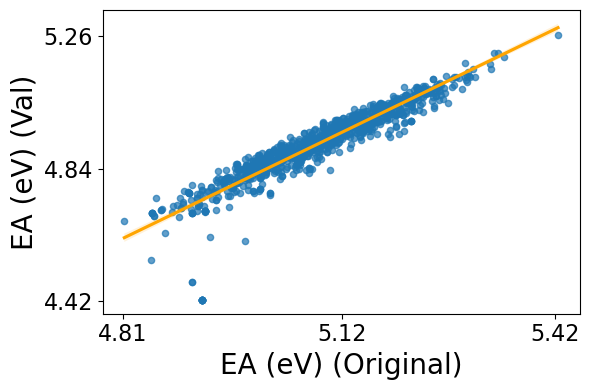

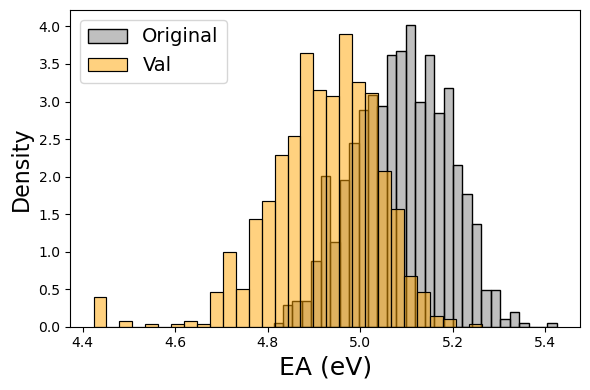

band_gap                  |  0.940 |     0.0116 |     0.0026


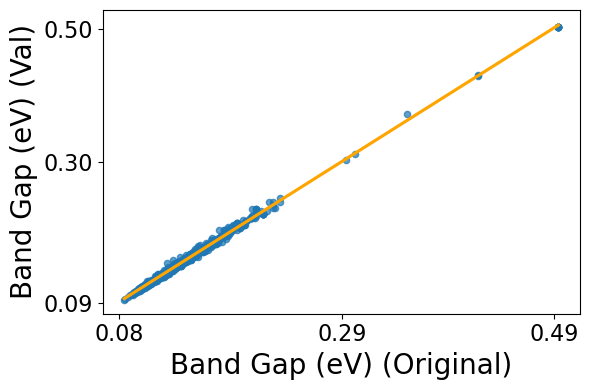

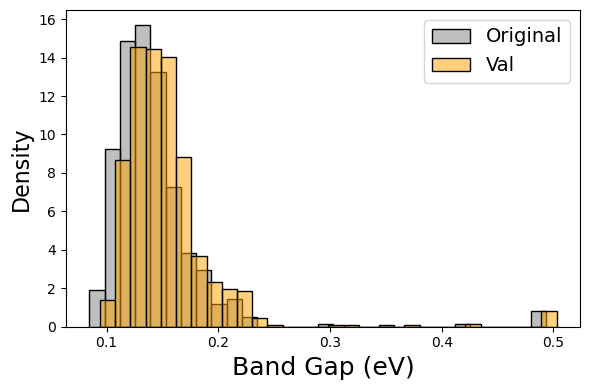

Fermi_energy              |  0.968 |     0.0180 |     0.0070


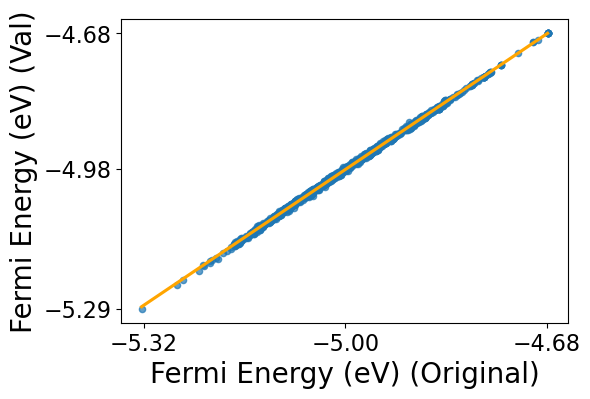

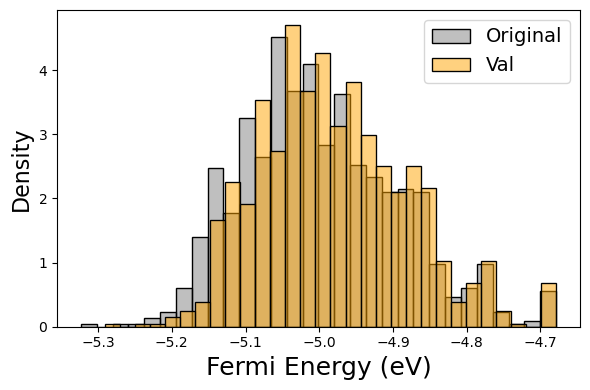

current                   |  0.945 |     0.4478 |     0.4037


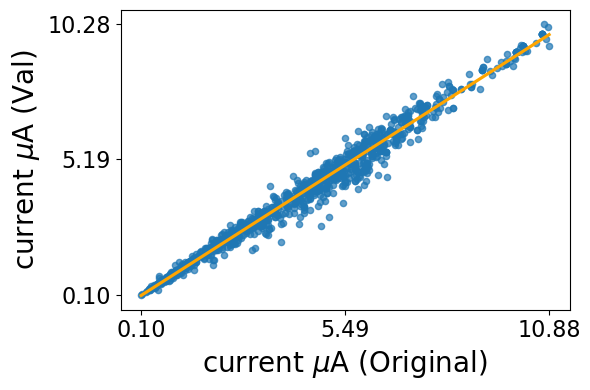

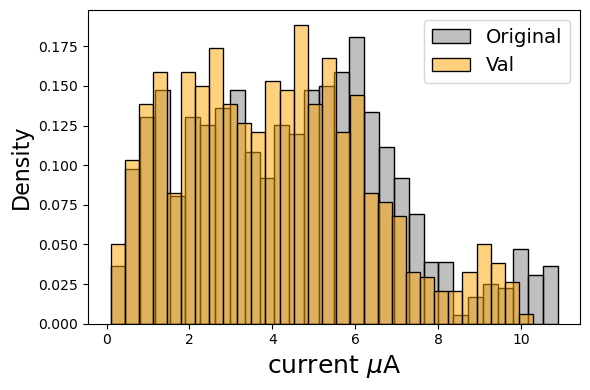

formation_energy          | -3.416 |     0.1415 |     0.0009


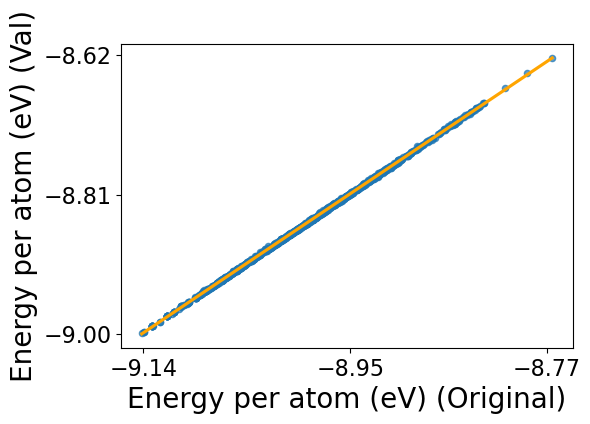

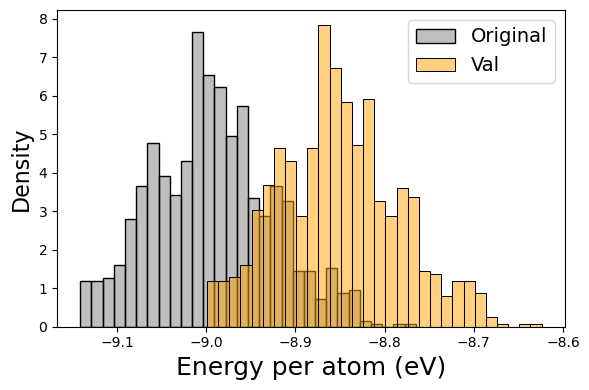

In [12]:


def get_num_atoms(file_xyz):
    try:
        with open(file_xyz, "r") as file:
            first_line = file.readline()
            n_atoms = int(first_line.strip())
            return n_atoms
    except Exception as e:
        print(f"Error: {e}")
        return None
    
def compare_pipeline(
    ref,
    mod,
    label,
    targets,
    x_labels,
    max_samples=1000,
    scale_current=1e6,
    reference_energy=-40.0549
):
    # --- Merge iniziale ---
    merged = pd.merge(
        ref[['file_name'] + targets],
        mod[['file_name', 'num_atoms','formation_energy_ev'] + targets],
        on='file_name',
        suffixes=('_ref', '_mod')
    )
    print(f"[{label}] Common files: {len(merged)}")
    print(merged.head())
    # --- Formation energy per atomo ---
    merged['formation_energy_ref'] = (
        merged['total_energy_ref'] - merged['num_atoms'] * reference_energy
    ) / merged['num_atoms']

    merged['formation_energy_mod'] = (
        merged['formation_energy_ev'] - merged['num_atoms'] * reference_energy
    ) / merged['num_atoms']
    merged.to_csv('merged_data.csv')
    # --- Selezione campioni ---
    if len(merged) > max_samples:
        merged = merged.sample(n=max_samples, random_state=42).reset_index(drop=True)

    # --- Aggiungi il nuovo target ---
    targets_ext = targets + ['formation_energy']
    x_labels_ext = x_labels + ['Energy per atom (eV)']

    print("\n=== Statistical Summary ===")
    print(f"{'Target':25s} | {'R²':>6s} | {'MAE (eV)':>10s} | {'σ (eV)':>10s}")
    print("-" * 60)

    # --- Loop sui target ---
    for target, x_label in zip(targets_ext, x_labels_ext):
        # gestione current
        if target == 'current':
            x = merged[f"{target}_ref"] * scale_current
            y = merged[f"{target}_mod"] * scale_current
        else:
            x = merged[f"{target}_ref"]
            y = merged[f"{target}_mod"]

        valid = x.notna() & y.notna()
        x = x[valid]
        y = y[valid]

        # --- Metriche ---
        r2 = r2_score(x, y)
        mae = np.mean(np.abs(y - x))
        std_dev = np.std(y - x)

        print(f"{target:25s} | {r2:6.3f} | {mae:10.4f} | {std_dev:10.4f}")

        # --- Plot 1: Scatter con regressione ---
        plt.figure(figsize=(6, 4))
        sns.regplot(
            x=x,
            y=y,
            scatter_kws={"s": 20, "alpha": 0.7},
            line_kws={"color": "orange"}
        )
        x_ticks = np.round(np.linspace(x.min(), x.max(), 3), 2)
        y_ticks = np.round(np.linspace(y.min(), y.max(), 3), 2)
        plt.xticks(x_ticks, fontsize=16)
        plt.yticks(y_ticks, fontsize=16)
        plt.xlabel(f"{x_label} (Original)", fontsize=20)
        plt.ylabel(f"{x_label} ({label})", fontsize=20)
        plt.tight_layout()
        plt.savefig(f"{target}_regplot.png", dpi=300)
        plt.show()

            # --- Plot 2: Istogramma comparativo ---
        plt.figure(figsize=(6, 4))
        x_np = np.asarray(x)
        y_np = np.asarray(y)

        # KDE solo se abbastanza dati (>30)
        kde_flag = False#len(x_np) > 30 and len(y_np) > 30

        sns.histplot(x_np, color="gray", label="Original",
                     kde=kde_flag, stat="density", bins=30, alpha=0.5)
        sns.histplot(y_np, color="orange", label=label,
                     kde=kde_flag, stat="density", bins=30, alpha=0.5)

        plt.xlabel(x_label, fontsize=18)
        plt.ylabel("Density", fontsize=16)
        plt.legend(fontsize=14)
        plt.tight_layout()
        plt.savefig(f"{target}_histogram.png", dpi=300)
        plt.show()

targets = ['total_energy', 'ionization_potential', 'electron_affinity', 'band_gap','Fermi_energy', 'current']

x_labels = ['Total Energy (eV)', 'IP (eV)', 
            'EA (eV)', 'Band Gap (eV)', 'Fermi Energy (eV)', r'current $\mu$A']
compare_pipeline(csv_ref, csv_mod, label="Val", targets=targets, x_labels=x_labels)